In [4]:
from pathlib import Path
import numpy as np
from PIL import Image

BASE_DIR = Path.cwd().parent

DATASET_DIR = (
    BASE_DIR
    / "dataset"
    / "Indian Spices Image Dataset"
)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

IMG_SIZE = (64, 64)

classes = sorted([
    folder.name
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

print("Dataset exists:", DATASET_DIR.exists())
print("Classes:", classes)

Dataset exists: True
Classes: ['Bay Leaf', 'Caraway seeds', 'Cloves', 'Mace', 'Stone Flowers']


In [7]:
from pathlib import Path

# Project root = one level above the notebooks folder
BASE_DIR = Path.cwd().parent

# Dataset location
DATASET_DIR = BASE_DIR / "dataset" / "Indian Spices Image Dataset"

print("Dataset path:")
print(DATASET_DIR)

print("\nDataset exists:", DATASET_DIR.exists())

Dataset path:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\dataset\Indian Spices Image Dataset

Dataset exists: True


In [5]:
# ============================================================
# LOAD IMAGES
# ============================================================

X = []
y = []

for class_name in classes:

    class_dir = DATASET_DIR / class_name

    image_files = [
        file
        for file in class_dir.rglob("*")
        if (
            file.is_file()
            and file.suffix.lower() in IMAGE_EXTENSIONS
        )
    ]

    print(
        f"Loading {class_name}: "
        f"{len(image_files)} images"
    )

    for image_path in image_files:

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

            image = image.resize(
                IMG_SIZE
            )

            image_array = np.array(
                image,
                dtype=np.float32
            )

            image_array = (
                image_array / 255.0
            )

            X.append(image_array)
            y.append(class_name)

        except Exception as e:

            print(
                f"Skipped {image_path.name}: {e}"
            )

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(y)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Loading Bay Leaf: 1085 images
Loading Caraway seeds: 1110 images
Loading Cloves: 827 images
Loading Mace: 854 images
Loading Stone Flowers: 877 images

X shape: (4753, 64, 64, 3)
y shape: (4753,)


In [9]:
# Count images in each class

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_counts = {}

for class_name in classes:
    class_dir = DATASET_DIR / class_name

    count = sum(
        1
        for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    )

    class_counts[class_name] = count

print("Image count per class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Image count per class:

Bay Leaf: 1085
Caraway seeds: 1110
Cloves: 827
Mace: 854
Stone Flowers: 877


In [6]:
# ============================================================
# LABEL ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")

for index, class_name in enumerate(
    label_encoder.classes_
):
    print(
        f"{index} → {class_name}"
    )

print("\nEncoded shape:", y_encoded.shape)

Class mapping:
0 → Bay Leaf
1 → Caraway seeds
2 → Cloves
3 → Mace
4 → Stone Flowers

Encoded shape: (4753,)


In [11]:
# Check image properties

sample_path = None

for class_name in classes:
    class_dir = DATASET_DIR / class_name

    image_files = [
        file for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    if image_files:
        sample_path = image_files[0]
        break

image = Image.open(sample_path)

print("Sample image:", sample_path.name)
print("Image size:", image.size)
print("Image mode:", image.mode)

Sample image: BayLeaf1.jpg
Image size: (1440, 1080)
Image mode: RGB


In [14]:
# ============================================================
# LOAD AND PREPROCESS ALL IMAGES
# ============================================================

# Image size for the ANN
IMG_SIZE = (64, 64)

# Supported image formats
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

# Empty lists for images and labels
X = []
y = []

print("Starting image loading...\n")


# ============================================================
# LOOP THROUGH EACH SPICE CLASS
# ============================================================

for class_name in classes:

    class_dir = DATASET_DIR / class_name

    # Find all image files
    image_files = [
        file
        for file in class_dir.rglob("*")
        if (
            file.is_file()
            and file.suffix.lower() in IMAGE_EXTENSIONS
        )
    ]

    print(
        f"Loading {class_name}: "
        f"{len(image_files)} images"
    )


    # ========================================================
    # LOAD EACH IMAGE
    # ========================================================

    for image_path in image_files:

        try:

            # Open image and convert to RGB
            image = Image.open(
                image_path
            ).convert("RGB")

            # Resize image
            image = image.resize(
                IMG_SIZE
            )

            # Convert image to NumPy array
            image_array = np.array(
                image,
                dtype=np.float32
            )

            # Normalize pixel values
            # 0-255 → 0-1
            image_array = (
                image_array / 255.0
            )

            # Store image
            X.append(
                image_array
            )

            # Store corresponding class
            y.append(
                class_name
            )

        except Exception as e:

            print(
                f"Skipped: {image_path.name} "
                f"| Error: {e}"
            )


# ============================================================
# CONVERT LISTS TO NUMPY ARRAYS
# ============================================================

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 50)

print("IMAGE LOADING COMPLETED")

print("=" * 50)

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "Image size:",
    IMG_SIZE
)

print(
    "Number of images:",
    len(X)
)

print(
    "Number of labels:",
    len(y)
)

Starting image loading...

Loading Bay Leaf: 1085 images
Loading Caraway seeds: 1110 images
Loading Cloves: 827 images
Loading Mace: 854 images
Loading Stone Flowers: 877 images

IMAGE LOADING COMPLETED
X shape: (4753, 64, 64, 3)
y shape: (4753,)
Image size: (64, 64)
Number of images: 4753
Number of labels: 4753


In [15]:
# ============================================================
# ENCODE SPICE LABELS
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Create label encoder
label_encoder = LabelEncoder()

# Convert spice names into numbers
y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
print("=" * 40)

for index, class_name in enumerate(label_encoder.classes_):
    print(f"{index} → {class_name}")

print("\nEncoded labels shape:", y_encoded.shape)
print("Unique encoded labels:", np.unique(y_encoded))

Class mapping:
0 → Bay Leaf
1 → Caraway seeds
2 → Cloves
3 → Mace
4 → Stone Flowers

Encoded labels shape: (4753,)
Unique encoded labels: [0 1 2 3 4]


In [16]:
# ============================================================
# FLATTEN IMAGES
# ============================================================

# ANN requires 2D input:
# (number of samples, number of features)

X_flat = X.reshape(
    X.shape[0],
    -1
)

print("Original X shape:")
print(X.shape)

print("\nFlattened X shape:")
print(X_flat.shape)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Original X shape:
(4753, 64, 64, 3)

Flattened X shape:
(4753, 12288)

Training data:
X_train: (3802, 12288)
y_train: (3802,)

Testing data:
X_test: (951, 12288)
y_test: (951,)


In [17]:
# ============================================================
# STANDARD SCALER
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Original training shape:")
print(X_train.shape)

print("\nScaled training shape:")
print(X_train_scaled.shape)

print("\nOriginal testing shape:")
print(X_test.shape)

print("\nScaled testing shape:")
print(X_test_scaled.shape)

Original training shape:
(3802, 12288)

Scaled training shape:
(3802, 12288)

Original testing shape:
(951, 12288)

Scaled testing shape:
(951, 12288)


In [7]:
# ============================================================
# BUILD ANN MODEL
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# Number of input features
input_features = X_train_scaled.shape[1]

# Number of spice classes
num_classes = len(label_encoder.classes_)

print("Input features:", input_features)
print("Number of classes:", num_classes)


# ============================================================
# CREATE MODEL
# ============================================================

model = Sequential([

    Dense(
        256,
        activation="relu",
        input_shape=(input_features,)
    ),

    Dropout(0.30),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        num_classes,
        activation="softmax"
    )
])


# ============================================================
# MODEL SUMMARY
# ============================================================

model.summary()

NameError: name 'X_train_scaled' is not defined

In [21]:
import sys
import numpy as np

print("Python:", sys.version)
print("NumPy:", np.__version__)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
NumPy: 2.4.6


In [23]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python executable:
c:\Program Files\Python311\python.exe

NumPy version:
2.4.6


In [25]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python executable:
c:\Program Files\Python311\python.exe

NumPy version:
2.4.6


In [26]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python executable:
c:\Program Files\Python311\python.exe

NumPy version:
2.4.6


In [27]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python executable:
c:\Program Files\Python311\python.exe

NumPy version:
2.4.6


In [29]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python executable:
c:\Program Files\Python311\python.exe

NumPy version:
2.4.6


In [8]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.15.0


In [32]:
import sys
import numpy as np

print(sys.executable)
print(np.__version__)

c:\Program Files\Python311\python.exe
2.4.6


In [1]:
import sys
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nNumPy:")
print(np.__version__)

Python executable:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\.venv\Scripts\python.exe

NumPy:
1.26.4


In [2]:
# ============================================================
# TEST TENSORFLOW
# ============================================================

import tensorflow as tf

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.15.0


In [3]:
# ============================================================
# BUILD ANN MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Number of input features
input_features = X_train_scaled.shape[1]

# Number of spice classes
num_classes = len(label_encoder.classes_)

print("Input features:", input_features)
print("Number of classes:", num_classes)

# Create ANN
model = Sequential([

    Dense(
        256,
        activation="relu",
        input_shape=(input_features,)
    ),

    Dropout(0.30),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        num_classes,
        activation="softmax"
    )
])

# Display model architecture
model.summary()

NameError: name 'X_train_scaled' is not defined

ENVIRONMENT
Python: c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\.venv\Scripts\python.exe
NumPy: 1.26.4
TensorFlow: 2.15.0

Classes: ['Bay Leaf', 'Caraway seeds', 'Cloves', 'Mace', 'Stone Flowers']
Number of classes: 5

LOADING IMAGES
Loading Bay Leaf: 1085 images
Loading Caraway seeds: 1110 images
Loading Cloves: 827 images
Loading Mace: 854 images
Loading Stone Flowers: 877 images

X shape: (4753, 64, 64, 3)
y shape: (4753,)
Skipped: 0

Label mapping:
0 -> Bay Leaf
1 -> Caraway seeds
2 -> Cloves
3 -> Mace
4 -> Stone Flowers

Flattened shape: (4753, 12288)
X_train: (3802, 12288)
X_test: (951, 12288)
X_train_scaled: (3802, 12288)
X_test_scaled: (951, 12288)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               3145984   
                                                                 
 dropout (Dropout)           (

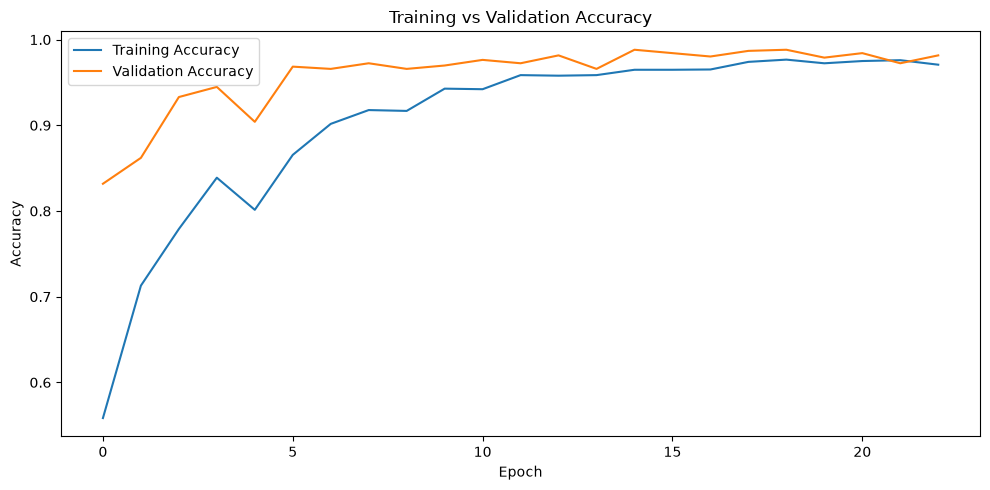


TEST RESULTS
Test Accuracy: 97.79%
Test Loss: 0.0859

CLASSIFICATION REPORT
               precision    recall  f1-score   support

     Bay Leaf       0.97      1.00      0.99       217
Caraway seeds       0.99      0.99      0.99       222
       Cloves       0.94      0.98      0.96       165
         Mace       0.99      0.99      0.99       171
Stone Flowers       0.99      0.93      0.96       176

     accuracy                           0.98       951
    macro avg       0.98      0.98      0.98       951
 weighted avg       0.98      0.98      0.98       951



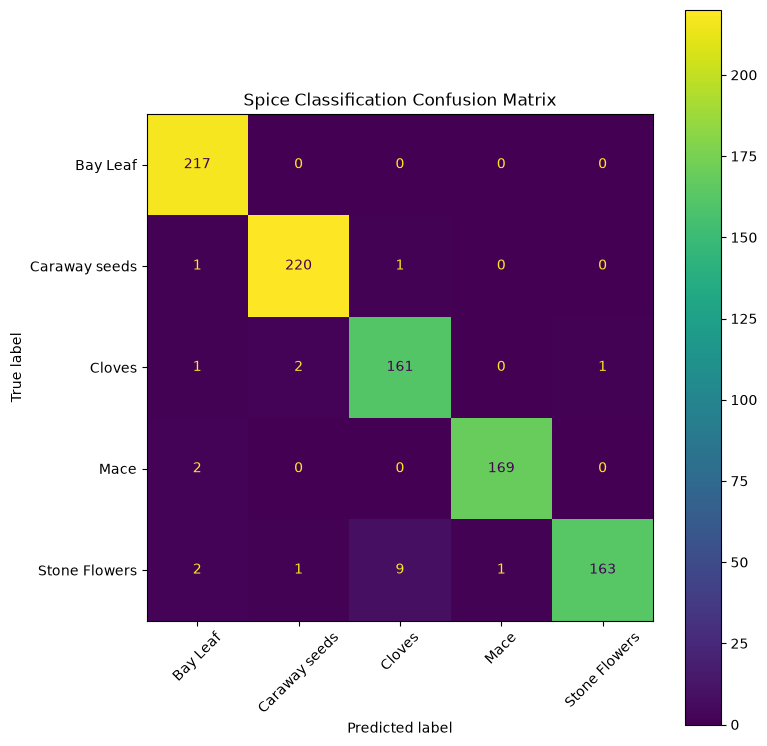


PROJECT COMPLETED
Model: c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\models\spice_model.keras
Scaler: c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\models\scaler.pkl
Encoder: c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\models\label_encoder.pkl
Final Test Accuracy: 97.79%


In [10]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib

print("="*60)
print("ENVIRONMENT")
print("="*60)
print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

BASE_DIR = Path.cwd().parent
DATASET_DIR = BASE_DIR / "dataset" / "Indian Spices Image Dataset"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_DIR}")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
IMG_SIZE = (64, 64)

classes = sorted([p.name for p in DATASET_DIR.iterdir() if p.is_dir()])
print("\nClasses:", classes)
print("Number of classes:", len(classes))

X, y = [], []
skipped = 0

print("\n" + "="*60)
print("LOADING IMAGES")
print("="*60)

for class_name in classes:
    class_dir = DATASET_DIR / class_name
    image_files = [p for p in class_dir.rglob("*")
                   if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
    print(f"Loading {class_name}: {len(image_files)} images")

    for image_path in image_files:
        try:
            image = Image.open(image_path).convert("RGB")
            image = image.resize(IMG_SIZE)
            arr = np.asarray(image, dtype=np.float32) / 255.0
            X.append(arr)
            y.append(class_name)
        except Exception as e:
            skipped += 1
            print(f"Skipped {image_path.name}: {e}")

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y)

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Skipped:", skipped)

if len(X) == 0:
    raise ValueError("No images were loaded.")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nLabel mapping:")
for i, name in enumerate(label_encoder.classes_):
    print(f"{i} -> {name}")

X_flat = X.reshape(X.shape[0], -1)
print("\nFlattened shape:", X_flat.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

input_features = X_train_scaled.shape[1]
num_classes = len(label_encoder.classes_)

model = Sequential([
    Dense(256, activation="relu", input_shape=(input_features,)),
    Dropout(0.30),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("\n" + "="*60)
print("TRAINING")
print("="*60)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

test_loss, test_accuracy = model.evaluate(
    X_test_scaled, y_test, verbose=0
)

print("\n" + "="*60)
print("TEST RESULTS")
print("="*60)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

y_probability = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_probability, axis=1)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Spice Classification Confusion Matrix")
plt.tight_layout()
plt.show()

MODEL_PATH = MODEL_DIR / "spice_model.keras"
SCALER_PATH = MODEL_DIR / "scaler.pkl"
ENCODER_PATH = MODEL_DIR / "label_encoder.pkl"

model.save(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(label_encoder, ENCODER_PATH)

print("\n" + "="*60)
print("PROJECT COMPLETED")
print("="*60)
print("Model:", MODEL_PATH)
print("Scaler:", SCALER_PATH)
print("Encoder:", ENCODER_PATH)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

In [11]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

               precision    recall  f1-score   support

     Bay Leaf       0.97      1.00      0.99       217
Caraway seeds       0.99      0.99      0.99       222
       Cloves       0.94      0.98      0.96       165
         Mace       0.99      0.99      0.99       171
Stone Flowers       0.99      0.93      0.96       176

     accuracy                           0.98       951
    macro avg       0.98      0.98      0.98       951
 weighted avg       0.98      0.98      0.98       951



Confusion Matrix:
[[217   0   0   0   0]
 [  1 220   1   0   0]
 [  1   2 161   0   1]
 [  2   0   0 169   0]
 [  2   1   9   1 163]]


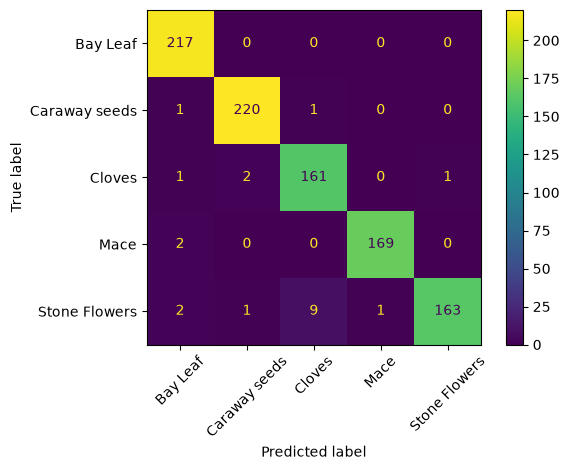

In [12]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=45
)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# TEST A NEW BAY LEAF IMAGE
# ============================================================

image_path = BASE_DIR / "test_images" / "bayleaf_test.jpg"

# Check image exists
print("Image path:")
print(image_path)

print("\nImage exists:", image_path.exists())

if not image_path.exists():
    raise FileNotFoundError(
        f"Image not found: {image_path}"
    )


# ============================================================
# LOAD IMAGE
# ============================================================

image = Image.open(
    image_path
).convert("RGB")


# ============================================================
# DISPLAY IMAGE
# ============================================================

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.axis("off")

plt.title("Test Bay Leaf Image")

plt.show()


# ============================================================
# RESIZE
# ============================================================

image = image.resize(
    (64, 64)
)


# ============================================================
# CONVERT TO NUMPY
# ============================================================

image_array = np.array(
    image,
    dtype=np.float32
)


# ============================================================
# NORMALIZE
# ============================================================

image_array = image_array / 255.0


# ============================================================
# FLATTEN
# ============================================================

image_flat = image_array.reshape(
    1,
    -1
)


print("Feature shape:", image_flat.shape)


# ============================================================
# SCALE
# ============================================================

image_scaled = scaler.transform(
    image_flat
)


# ============================================================
# PREDICT
# ============================================================

probabilities = model.predict(
    image_scaled,
    verbose=0
)


# ============================================================
# FIND PREDICTION
# ============================================================

predicted_index = np.argmax(
    probabilities[0]
)

confidence = probabilities[0][
    predicted_index
]


# ============================================================
# DECODE CLASS
# ============================================================

predicted_class = (
    label_encoder.inverse_transform(
        [predicted_index]
    )[0]
)


# ============================================================
# DISPLAY RESULT
# ============================================================

print("\n" + "=" * 50)

print(
    "Predicted spice:",
    predicted_class
)

print(
    f"Confidence: "
    f"{confidence * 100:.2f}%"
)

print("=" * 50)


# ============================================================
# ALL CLASS PROBABILITIES
# ============================================================

print("\nAll probabilities:")

for class_name, probability in zip(
    label_encoder.classes_,
    probabilities[0]
):

    print(
        f"{class_name}: "
        f"{probability * 100:.2f}%"
    )

Image path:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\test_images\bayleaf_test.jpg

Image exists: False


FileNotFoundError: Image not found: c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\test_images\bayleaf_test.jpg

Selected image:
C:/Users/sarag/OneDrive/Desktop/Indian_Spice_Classification_New/dataset/Indian Spices Image Dataset/Mace/Mace1.jpg


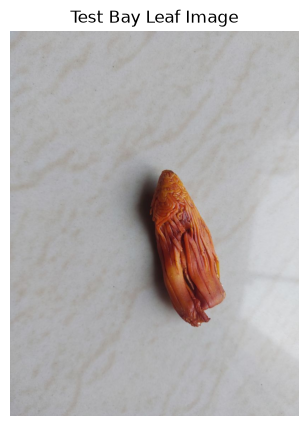


Predicted spice: Mace
Confidence: 100.00%

All probabilities:
Bay Leaf: 0.00%
Caraway seeds: 0.00%
Cloves: 0.00%
Mace: 100.00%
Stone Flowers: 0.00%


In [15]:
# ============================================================
# TEST A NEW IMAGE
# ============================================================

from tkinter import Tk, filedialog

# Open Windows file picker
root = Tk()
root.withdraw()

image_path = filedialog.askopenfilename(
    title="Select a Bay Leaf Image",
    filetypes=[
        ("Image files", "*.jpg *.jpeg *.png *.bmp *.webp")
    ]
)

root.destroy()


# ============================================================
# CHECK SELECTION
# ============================================================

if not image_path:

    print("❌ No image selected.")

else:

    print("Selected image:")
    print(image_path)


    # ========================================================
    # LOAD IMAGE
    # ========================================================

    image = Image.open(
        image_path
    ).convert("RGB")


    # ========================================================
    # DISPLAY IMAGE
    # ========================================================

    plt.figure(figsize=(5, 5))

    plt.imshow(image)

    plt.axis("off")

    plt.title("Test Bay Leaf Image")

    plt.show()


    # ========================================================
    # PREPROCESS
    # ========================================================

    image = image.resize(
        (64, 64)
    )

    image_array = np.array(
        image,
        dtype=np.float32
    )

    image_array = (
        image_array / 255.0
    )

    image_flat = image_array.reshape(
        1, -1
    )


    # ========================================================
    # SCALE
    # ========================================================

    image_scaled = scaler.transform(
        image_flat
    )


    # ========================================================
    # PREDICT
    # ========================================================

    probabilities = model.predict(
        image_scaled,
        verbose=0
    )


    predicted_index = np.argmax(
        probabilities[0]
    )

    confidence = probabilities[0][
        predicted_index
    ]


    predicted_class = (
        label_encoder.inverse_transform(
            [predicted_index]
        )[0]
    )


    # ========================================================
    # RESULT
    # ========================================================

    print("\n" + "=" * 50)

    print(
        "Predicted spice:",
        predicted_class
    )

    print(
        f"Confidence: "
        f"{confidence * 100:.2f}%"
    )

    print("=" * 50)


    # ========================================================
    # ALL PROBABILITIES
    # ========================================================

    print("\nAll probabilities:")

    for class_name, probability in zip(
        label_encoder.classes_,
        probabilities[0]
    ):

        print(
            f"{class_name}: "
            f"{probability * 100:.2f}%"
        )

In [16]:
# ============================================================
# TEST A BAY LEAF FROM THE TEST SET
# ============================================================

# Find the encoded number for Bay Leaf
bay_leaf_index = np.where(
    label_encoder.classes_ == "Bay Leaf"
)[0][0]

# Find Bay Leaf images in the test set
bay_leaf_positions = np.where(
    y_test == bay_leaf_index
)[0]

print("Bay Leaf test images:", len(bay_leaf_positions))

# Take the first Bay Leaf test image
test_position = bay_leaf_positions[0]

# Get prediction
probabilities = model.predict(
    X_test_scaled[test_position:test_position + 1],
    verbose=0
)

predicted_index = np.argmax(
    probabilities[0]
)

predicted_class = label_encoder.inverse_transform(
    [predicted_index]
)[0]

confidence = probabilities[0][predicted_index]

print("\nActual class:")
print("Bay Leaf")

print("\nPredicted class:")
print(predicted_class)

print(
    f"\nConfidence: {confidence * 100:.2f}%"
)

print("\nAll probabilities:")

for class_name, probability in zip(
    label_encoder.classes_,
    probabilities[0]
):
    print(
        f"{class_name}: {probability * 100:.2f}%"
    )

Bay Leaf test images: 217

Actual class:
Bay Leaf

Predicted class:
Bay Leaf

Confidence: 100.00%

All probabilities:
Bay Leaf: 100.00%
Caraway seeds: 0.00%
Cloves: 0.00%
Mace: 0.00%
Stone Flowers: 0.00%


In [17]:
# ============================================================
# DATA AUGMENTATION FOR ANN
# ============================================================

from PIL import ImageEnhance
import random

# Number of augmented copies per original training image
AUGMENT_COPIES = 1

X_augmented = []
y_augmented = []

print("Creating augmented training images...")

for image_array, label in zip(X_train, y_train):

    # --------------------------------------------------------
    # Original image is currently flattened.
    # Convert it back to 64x64x3
    # --------------------------------------------------------

    image_array = image_array.reshape(
        64,
        64,
        3
    )

    # Convert from 0-1 back to 0-255
    image_uint8 = (
        image_array * 255
    ).clip(
        0,
        255
    ).astype(
        np.uint8
    )

    image = Image.fromarray(
        image_uint8
    )

    # --------------------------------------------------------
    # Random horizontal flip
    # --------------------------------------------------------

    if random.random() < 0.5:

        image = image.transpose(
            Image.Transpose.FLIP_LEFT_RIGHT
        )

    # --------------------------------------------------------
    # Random brightness
    # --------------------------------------------------------

    brightness_factor = random.uniform(
        0.8,
        1.2
    )

    enhancer = ImageEnhance.Brightness(
        image
    )

    image = enhancer.enhance(
        brightness_factor
    )

    # --------------------------------------------------------
    # Convert back to NumPy
    # --------------------------------------------------------

    augmented_array = np.array(
        image,
        dtype=np.float32
    )

    # Normalize
    augmented_array = (
        augmented_array / 255.0
    )

    # Flatten
    augmented_flat = augmented_array.reshape(
        -1
    )

    X_augmented.append(
        augmented_flat
    )

    y_augmented.append(
        label
    )


# ============================================================
# CONVERT AUGMENTED DATA
# ============================================================

X_augmented = np.array(
    X_augmented,
    dtype=np.float32
)

y_augmented = np.array(
    y_augmented
)

print(
    "Augmented X shape:",
    X_augmented.shape
)

print(
    "Augmented y shape:",
    y_augmented.shape
)

Creating augmented training images...
Augmented X shape: (3802, 12288)
Augmented y shape: (3802,)


In [18]:
# ============================================================
# COMBINE ORIGINAL + AUGMENTED TRAINING DATA
# ============================================================

# Combine original training data with augmented data
X_train_combined = np.concatenate(
    [
        X_train,
        X_augmented
    ],
    axis=0
)

y_train_combined = np.concatenate(
    [
        y_train,
        y_augmented
    ],
    axis=0
)


print("Original training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nAugmented data:")
print("X_augmented:", X_augmented.shape)
print("y_augmented:", y_augmented.shape)

print("\nCombined training data:")
print("X_train_combined:", X_train_combined.shape)
print("y_train_combined:", y_train_combined.shape)

Original training data:
X_train: (3802, 12288)
y_train: (3802,)

Augmented data:
X_augmented: (3802, 12288)
y_augmented: (3802,)

Combined training data:
X_train_combined: (7604, 12288)
y_train_combined: (7604,)


In [19]:
# ============================================================
# SCALE COMBINED TRAINING DATA
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create a NEW scaler for the augmented dataset
scaler_augmented = StandardScaler()

# Fit only on combined training data
X_train_combined_scaled = scaler_augmented.fit_transform(
    X_train_combined
)

# IMPORTANT:
# Test data remains completely untouched.
# Transform it using the new scaler.
X_test_scaled_augmented = scaler_augmented.transform(
    X_test
)

print("Combined training data:")
print(
    "X_train_combined_scaled:",
    X_train_combined_scaled.shape
)

print("\nTest data:")
print(
    "X_test_scaled_augmented:",
    X_test_scaled_augmented.shape
)

Combined training data:
X_train_combined_scaled: (7604, 12288)

Test data:
X_test_scaled_augmented: (951, 12288)


In [20]:
# ============================================================
# BUILD NEW ANN WITH AUGMENTED DATA
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

input_features = X_train_combined_scaled.shape[1]
num_classes = len(label_encoder.classes_)

print("Input features:", input_features)
print("Number of classes:", num_classes)

model_augmented = Sequential([
    
    Dense(
        256,
        activation="relu",
        input_shape=(input_features,)
    ),

    Dropout(0.30),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        num_classes,
        activation="softmax"
    )
])

# Compile
model_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n✅ New ANN compiled successfully.")

model_augmented.summary()

Input features: 12288
Number of classes: 5

✅ New ANN compiled successfully.
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               3145984   
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                           

In [21]:
# ============================================================
# TRAIN AUGMENTED ANN
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_augmented = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("=" * 60)
print("TRAINING AUGMENTED ANN")
print("=" * 60)

history_augmented = model_augmented.fit(
    X_train_combined_scaled,
    y_train_combined,

    validation_split=0.20,

    epochs=30,

    batch_size=32,

    callbacks=[
        early_stopping_augmented
    ],

    verbose=1
)

print("\n✅ Training completed.")

TRAINING AUGMENTED ANN
Epoch 1/30
191/191 [==============================] - 11s 51ms/step - loss: 2.1296 - accuracy: 0.5270 - val_loss: 0.8185 - val_accuracy: 0.6884
Epoch 2/30
191/191 [==============================] - 9s 50ms/step - loss: 0.9917 - accuracy: 0.6755 - val_loss: 0.5877 - val_accuracy: 0.7830
Epoch 3/30
191/191 [==============================] - 10s 50ms/step - loss: 0.6618 - accuracy: 0.7814 - val_loss: 0.4254 - val_accuracy: 0.8580
Epoch 4/30
191/191 [==============================] - 9s 48ms/step - loss: 0.4819 - accuracy: 0.8453 - val_loss: 0.3283 - val_accuracy: 0.8843
Epoch 5/30
191/191 [==============================] - 9s 47ms/step - loss: 0.3623 - accuracy: 0.8803 - val_loss: 0.2788 - val_accuracy: 0.9145
Epoch 6/30
191/191 [==============================] - 9s 47ms/step - loss: 0.3568 - accuracy: 0.8839 - val_loss: 0.2736 - val_accuracy: 0.9093
Epoch 7/30
191/191 [==============================] - 9s 47ms/step - loss: 0.2596 - accuracy: 0.9155 - val_loss: 0.18

IMPROVED ANN - TEST EVALUATION
Test Loss: 0.0887
Test Accuracy: 98.00%

CLASSIFICATION REPORT
               precision    recall  f1-score   support

     Bay Leaf       0.99      1.00      0.99       217
Caraway seeds       0.98      0.99      0.98       222
       Cloves       0.97      0.95      0.96       165
         Mace       0.99      0.99      0.99       171
Stone Flowers       0.98      0.97      0.97       176

     accuracy                           0.98       951
    macro avg       0.98      0.98      0.98       951
 weighted avg       0.98      0.98      0.98       951


CONFUSION MATRIX
[[216   1   0   0   0]
 [  0 219   2   0   1]
 [  1   3 156   2   3]
 [  1   0   0 170   0]
 [  1   1   3   0 171]]


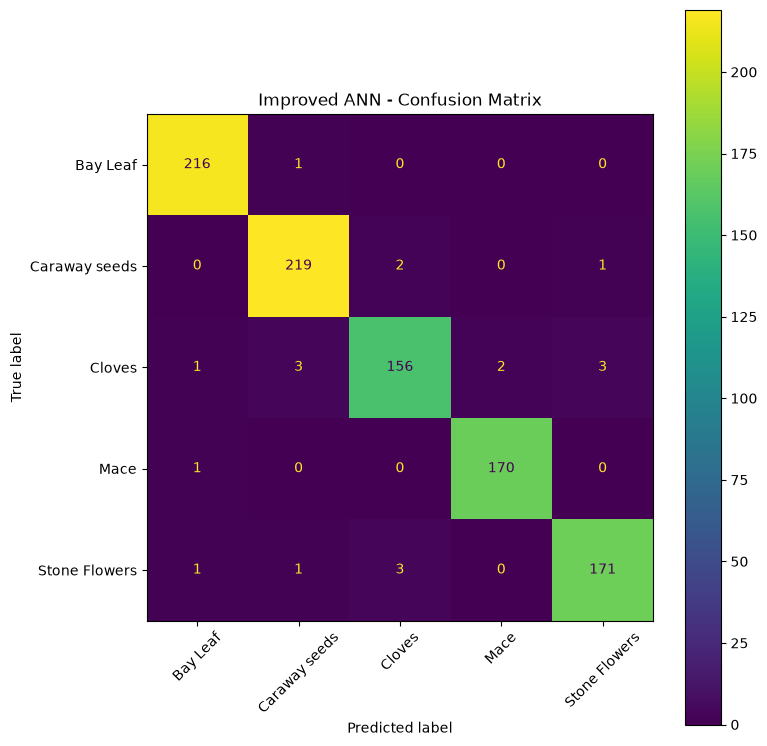

In [22]:
# ============================================================
# EVALUATE IMPROVED ANN
# ============================================================

print("=" * 60)
print("IMPROVED ANN - TEST EVALUATION")
print("=" * 60)

# Evaluate on the original untouched test set
test_loss_aug, test_accuracy_aug = model_augmented.evaluate(
    X_test_scaled_augmented,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss_aug:.4f}")
print(f"Test Accuracy: {test_accuracy_aug * 100:.2f}%")


# ============================================================
# PREDICTIONS
# ============================================================

y_probability_aug = model_augmented.predict(
    X_test_scaled_augmented,
    verbose=0
)

y_pred_aug = np.argmax(
    y_probability_aug,
    axis=1
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_aug,
        target_names=label_encoder.classes_
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm_aug = confusion_matrix(
    y_test,
    y_pred_aug
)

print(cm_aug)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_aug,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "Improved ANN - Confusion Matrix"
)

plt.tight_layout()
plt.show()

Selected: C:/Users/sarag/OneDrive/Desktop/Indian_Spice_Classification_New/dataset/Indian Spices Image Dataset/Cloves/Cloves3.jpg


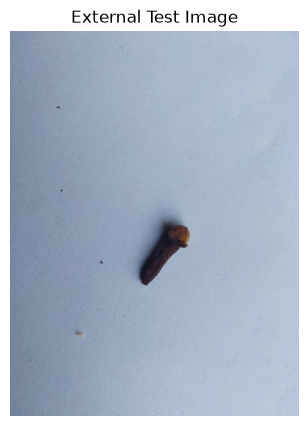


PREDICTION RESULT
Predicted spice: Cloves
Confidence: 100.00%

All probabilities:
Bay Leaf: 0.00%
Caraway seeds: 0.00%
Cloves: 100.00%
Mace: 0.00%
Stone Flowers: 0.00%


In [23]:
# ============================================================
# TEST EXTERNAL IMAGE WITH IMPROVED ANN
# ============================================================

from tkinter import Tk, filedialog

# Open file picker
root = Tk()
root.withdraw()

image_path = filedialog.askopenfilename(
    title="Select a Bay Leaf Image",
    filetypes=[
        ("Image files", "*.jpg *.jpeg *.png *.bmp *.webp")
    ]
)

root.destroy()

if not image_path:
    print("No image selected.")

else:
    print("Selected:", image_path)

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title("External Test Image")
    plt.show()

    # Resize exactly like training
    image = image.resize((64, 64))

    # Convert to NumPy
    image_array = np.array(
        image,
        dtype=np.float32
    )

    # Normalize
    image_array = image_array / 255.0

    # Flatten
    image_flat = image_array.reshape(1, -1)

    # IMPORTANT: use the scaler from augmented training
    image_scaled = scaler_augmented.transform(
        image_flat
    )

    # Predict with improved model
    probabilities = model_augmented.predict(
        image_scaled,
        verbose=0
    )

    predicted_index = np.argmax(
        probabilities[0]
    )

    predicted_class = label_encoder.inverse_transform(
        [predicted_index]
    )[0]

    confidence = probabilities[0][predicted_index]

    print("\n" + "=" * 50)
    print("PREDICTION RESULT")
    print("=" * 50)

    print("Predicted spice:", predicted_class)
    print(f"Confidence: {confidence * 100:.2f}%")

    print("\nAll probabilities:")

    for class_name, probability in zip(
        label_encoder.classes_,
        probabilities[0]
    ):
        print(
            f"{class_name}: "
            f"{probability * 100:.2f}%"
        )

In [24]:
# ============================================================
# SAVE IMPROVED ANN MODEL
# ============================================================

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "spice_model_augmented.keras"
SCALER_PATH = MODEL_DIR / "scaler_augmented.pkl"
ENCODER_PATH = MODEL_DIR / "label_encoder.pkl"

# Save model
model_augmented.save(MODEL_PATH)

# Save scaler
joblib.dump(
    scaler_augmented,
    SCALER_PATH
)

# Save label encoder
joblib.dump(
    label_encoder,
    ENCODER_PATH
)

print("=" * 60)
print("IMPROVED MODEL SAVED")
print("=" * 60)

print("Model:")
print(MODEL_PATH)

print("\nScaler:")
print(SCALER_PATH)

print("\nLabel encoder:")
print(ENCODER_PATH)

IMPROVED MODEL SAVED
Model:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\models\spice_model_augmented.keras

Scaler:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\models\scaler_augmented.pkl

Label encoder:
c:\Users\sarag\OneDrive\Desktop\Indian_Spice_Classification_New\models\label_encoder.pkl
